# Phase 4 — Temporal SHAP Drift Analysis (Static GCN **and** EvolveGCN-H)
**Purpose:** Compute time-indexed SHAP feature importances across 4 windows and detect
decision-logic drift with Kendall τ rank correlation — for BOTH models.

**How to run:** set `MODEL_NAME = 'static'`, run the whole notebook, then set
`MODEL_NAME = 'evolvegcn'` and run again. Outputs are namespaced by model, so nothing
is overwritten. The make-or-break comparison is **W3→W4 τ (EvolveGCN) vs 0.147 (Static)**.

### What this notebook produces (per model)
1. SHAP feature-importance rankings per time window
2. Kendall τ across windows + bootstrap 95% CI and permutation p-value (X4)
3. Local-vs-aggregated feature-shift analysis (X5)
4. T43 prediction table (false negatives at shutdown)

### Framing (important — X1)
These SHAP values come from a **no-edge, feature-only** forward pass (empty `edge_index`,
so each node is explained independently through self-loops). This is intentional: we use
SHAP as **feature-level model-behaviour monitoring**, NOT graph/edge attribution. With
anonymised Elliptic features we cannot verify per-transaction explanations, so τ on the
feature-importance ranking is a *model-risk / drift* signal, not a regulatory explanation.

### Time windows
| Window | Snapshots | Indices |
|--------|-----------|---------|
| W1 | T1–T10  | 0–9  |
| W2 | T11–T20 | 10–19 |
| W3 | T21–T30 | 20–29 |
| W4 | T31–T49 | 30–48 (contains T43) |

---
## Cell 1 — Install Dependencies

In [19]:
# ── Dependencies (Google Colab) ───────────────────────────────────────────────
# torch is pre-installed on Colab. Modern torch-geometric (>=2.4) does NOT need
# torch-scatter / torch-sparse for anything used in this project (GCNConv,
# scatter_add, add_self_loops, degree, to_undirected) — it falls back to native
# torch, so this install is fast and robust across torch versions.
import torch
print(f'PyTorch : {torch.__version__}   |   CUDA available : {torch.cuda.is_available()}')

!pip install -q torch-geometric
!pip install -q shap scikit-learn matplotlib seaborn numpy

# Optional — only if some op ever demands the compiled kernels (normally NOT needed):
# v  = torch.__version__.split('+')[0]
# cu = ('cu' + torch.version.cuda.replace('.', '')) if torch.cuda.is_available() else 'cpu'
# !pip install -q torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-{v}+{cu}.html

print('Dependencies installed.')

PyTorch : 2.11.0+cpu   |   CUDA available : False
Dependencies installed.


---
## Cell 2 — Imports & Global Config

In [20]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
import os
import json
import pickle
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.utils import add_self_loops, degree
import shap
from scipy.stats import kendalltau
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib
matplotlib.rcParams.update({'figure.dpi': 120, 'font.size': 11})

# ── Paths (unified BASE_DIR) ──────────────────────────────────────────────────
BASE_DIR      = '/content/drive/MyDrive/Capstone/Testing'
PROCESSED_DIR = os.path.join(BASE_DIR, 'data', 'processed')
MODELS_DIR    = os.path.join(BASE_DIR, 'models')
FIGURES_DIR   = os.path.join(BASE_DIR, 'figures')
SHAP_DIR      = os.path.join(BASE_DIR, 'data', 'shap')
for d in [FIGURES_DIR, SHAP_DIR]:
    os.makedirs(d, exist_ok=True)

# ══ SELECT THE MODEL TO EXPLAIN ═══════════════════════════════════════════════
MODEL_NAME = 'evolvegcn'          # 'static'  → run, then switch to 'evolvegcn' and re-run
# ══════════════════════════════════════════════════════════════════════════════
assert MODEL_NAME in ('static', 'evolvegcn')
MODEL_FILE = {'static': 'static_gcn_best.pt', 'evolvegcn': 'evolvegcn_best.pt'}[MODEL_NAME]

def shap_path(w):
    return os.path.join(SHAP_DIR, f'shap_{MODEL_NAME}_{w}.pkl')
TAU_JSON = os.path.join(SHAP_DIR, f'kendall_tau_{MODEL_NAME}.json')

# ── Constants ─────────────────────────────────────────────────────────────────
SEED          = 42
IN_CHANNELS   = 165
HIDDEN1       = 64
HIDDEN2       = 32
DROPOUT       = 0.5
SHUTDOWN_STEP = 43
NUM_FEATURES  = 165
feature_names = [f'feat_{i}' for i in range(NUM_FEATURES)]
LOCAL_MAX     = 93   # feat_0..feat_93 = local; feat_94..feat_164 = aggregated (X5)

# ── SHAP config ───────────────────────────────────────────────────────────────
N_BACKGROUND           = 100
N_SHAP_SAMPLES         = 200    # X3: bump to >=512 for the FINAL run to cut ranking noise
TOP_K                  = 10
TOP_K_TAU              = 15     # HARD INVARIANT — do not change
TAU_THRESHOLD          = 0.70
MAX_ILLICIT_PER_WINDOW = 1600
N_BOOTSTRAP            = 1000   # X4: bootstrap resamples for τ confidence interval
N_PERMUTATION          = 1000   # X4: permutation-test iterations

# ── Time windows (0-based snapshot indices) ───────────────────────────────────
WINDOWS = {
    'W1': list(range(0,  10)),
    'W2': list(range(10, 20)),
    'W3': list(range(20, 30)),
    'W4': list(range(30, 49)),   # contains T43 shutdown
}

torch.manual_seed(SEED)
np.random.seed(SEED)

print(f'Config loaded.  MODEL_NAME = {MODEL_NAME}   ({MODEL_FILE})')
for w, idx in WINDOWS.items():
    print(f'  {w}: T{idx[0]+1}–T{idx[-1]+1}  ({len(idx)} snapshots)')
print(f'  SHAP files  → shap_{MODEL_NAME}_W*.pkl')
print(f'  Kendall τ   → {os.path.basename(TAU_JSON)}')

Config loaded.  MODEL_NAME = evolvegcn   (evolvegcn_best.pt)
  W1: T1–T10  (10 snapshots)
  W2: T11–T20  (10 snapshots)
  W3: T21–T30  (10 snapshots)
  W4: T31–T49  (19 snapshots)
  SHAP files  → shap_evolvegcn_W*.pkl
  Kendall τ   → kendall_tau_evolvegcn.json


---
## Cell 3 — Device Setup

In [22]:
# SHAP runs on CPU regardless — move model to CPU for SHAP
# GPU is used only for predictions outside SHAP
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f'Primary device : {device}')
print(f'SHAP device    : cpu  (KernelSHAP always runs on CPU)')

Primary device : cpu
SHAP device    : cpu  (KernelSHAP always runs on CPU)


---
## Cell 4 — Load Snapshots

In [23]:
snapshots_path = os.path.join(PROCESSED_DIR, 'snapshots.pt')
snapshots = torch.load(snapshots_path, weights_only=False)

print(f'Snapshots loaded : {len(snapshots)}')
print(f'Feature dim      : {snapshots[0].x.shape[1]}')

# Quick window summary
print()
print('Window composition:')
for w, idx in WINDOWS.items():
    snaps      = [snapshots[i] for i in idx]
    total_nodes   = sum(s.num_nodes for s in snaps)
    total_illicit = int(sum(s.y.sum().item() for s in snaps))
    total_licit   = total_nodes - total_illicit
    print(f'  {w}: {total_nodes:,} nodes  |  {total_illicit:,} illicit  |  {total_licit:,} licit')

Snapshots loaded : 49
Feature dim      : 165

Window composition:
  W1: 58,097 nodes  |  -45,105 illicit  |  103,202 licit
  W2: 32,665 nodes  |  -24,997 illicit  |  57,662 licit
  W3: 32,525 nodes  |  -23,326 illicit  |  55,851 licit
  W4: 80,482 nodes  |  -59,232 illicit  |  139,714 licit


---
## Cell 5 — Define & Load Static GCN

In [24]:
# ── Model definitions (both self-contained so this notebook stands alone) ──────

class StaticGCN(nn.Module):
    def __init__(self, in_channels=IN_CHANNELS, hidden1=HIDDEN1,
                 hidden2=HIDDEN2, dropout=DROPOUT):
        super().__init__()
        self.conv1      = GCNConv(in_channels, hidden1)
        self.conv2      = GCNConv(hidden1, hidden2)
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden2, 2)
    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index); x = F.relu(x); x = self.dropout(x)
        x = self.conv2(x, edge_index); x = F.relu(x)
        return self.classifier(x), x


class EvolveGCNLayer(nn.Module):
    """Mirror of notebook 03 (learnable W0 seed, evolved W_state is a plain tensor)."""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.in_channels, self.out_channels = in_channels, out_channels
        self.gru = nn.GRUCell(input_size=in_channels, hidden_size=in_channels)
        self.W0  = nn.Parameter(torch.empty(out_channels, in_channels))
        nn.init.xavier_uniform_(self.W0)
        self.W_state = None
    def reset_state(self, device=None):
        self.W_state = self.W0.clone()
    def forward(self, x, edge_index):
        if self.W_state is None: self.reset_state()
        if self.W_state.device != x.device: self.W_state = self.W_state.to(x.device)
        z = x.mean(dim=0).unsqueeze(0).repeat(self.out_channels, 1)
        W_evolved = self.gru(z, self.W_state)
        self.W_state = W_evolved.detach()
        edge_index_sl, _ = add_self_loops(edge_index, num_nodes=x.size(0))
        row, col = edge_index_sl
        deg = degree(col, x.size(0), dtype=x.dtype)
        dinv = deg.pow(-0.5); dinv[dinv == float('inf')] = 0
        norm = dinv[row] * dinv[col]
        agg = torch.zeros(x.size(0), x.size(1), device=x.device, dtype=x.dtype)
        agg.scatter_add_(0, col.unsqueeze(1).expand(-1, x.size(1)), norm.unsqueeze(1) * x[row])
        return F.linear(agg, W_evolved)


class EvolveGCNH(nn.Module):
    def __init__(self, in_channels=IN_CHANNELS, hidden1=HIDDEN1, hidden2=HIDDEN2):
        super().__init__()
        self.layer1     = EvolveGCNLayer(in_channels, hidden1)
        self.layer2     = EvolveGCNLayer(hidden1,     hidden2)
        self.classifier = nn.Linear(hidden2, 2)
    def forward(self, x, edge_index):
        x = F.relu(self.layer1(x, edge_index))
        x = F.dropout(x, p=DROPOUT, training=self.training)
        x = F.relu(self.layer2(x, edge_index))
        return self.classifier(x), x
    def reset_state(self, device=None):
        self.layer1.reset_state(device); self.layer2.reset_state(device)


# ── Load the selected model (SHAP always on CPU) ──────────────────────────────
model_path = os.path.join(MODELS_DIR, MODEL_FILE)
if MODEL_NAME == 'static':
    model = StaticGCN()
else:
    model = EvolveGCNH()
model.load_state_dict(torch.load(model_path, map_location='cpu', weights_only=True))
model.eval()

print(f'{MODEL_NAME} model loaded from : {model_path}')
print(f'Parameters                : {sum(p.numel() for p in model.parameters()):,}')

evolvegcn model loaded from : /content/drive/MyDrive/Capstone/Testing/models/evolvegcn_best.pt
Parameters                : 201,974


---
## Build the SHAP predictor  (X1 — feature-level model-behaviour monitoring)
KernelSHAP is model-agnostic and works on tabular inputs. We wrap the model so it takes a
numpy feature matrix and returns illicit probabilities, using an **empty `edge_index`**:
each node is explained independently through self-loops. We are explaining **node features**,
not graph structure — this is intentional model-monitoring, not edge attribution. For
EvolveGCN we first warm up through the window to obtain that window's evolved weights,
then freeze them so SHAP sees a fixed feature→probability map.

In [25]:
def collect_window_data(idx_list):
    """Concatenate node features + labels across all snapshots in a window."""
    X_list, y_list = [], []
    for i in idx_list:
        s = snapshots[i]
        X_list.append(s.x.numpy())
        y_list.append(s.y.numpy())
    return np.concatenate(X_list, 0), np.concatenate(y_list, 0)


# ── Per-window predictor: numpy (N,165) → P(illicit) (N,) ─────────────────────
# Both models use an EMPTY edge_index (feature-only, self-loop) forward pass — the
# X1 framing. For EvolveGCN we first WARM UP through the window to obtain that
# window's evolved weights, then freeze them so SHAP sees a fixed feature→prob map.

if MODEL_NAME == 'static':
    def make_predictor(idx_list):
        def predictor(x_numpy):
            xt = torch.tensor(x_numpy, dtype=torch.float32)
            ei = torch.zeros((2, 0), dtype=torch.long)
            with torch.no_grad():
                logits, _ = model(xt, ei)
                return torch.softmax(logits, dim=1)[:, 1].numpy()
        return predictor
else:
    def _window_weights(last_idx):
        """Warm up EvolveGCN from T1 to `last_idx`; return the evolved weights there."""
        model.eval()
        model.reset_state('cpu')
        with torch.no_grad():
            for i in range(0, last_idx + 1):
                model(snapshots[i].x, snapshots[i].edge_index)
        return (model.layer1.W_state.detach().clone(),
                model.layer2.W_state.detach().clone(),
                model.classifier.weight.detach().clone(),
                model.classifier.bias.detach().clone())

    def make_predictor(idx_list):
        W1, W2, cw, cb = _window_weights(idx_list[-1])   # weights at window end
        def predictor(x_numpy):
            xt = torch.tensor(x_numpy, dtype=torch.float32)
            with torch.no_grad():
                h = torch.relu(F.linear(xt, W1))     # empty-edge → agg == x (self-loop)
                h = torch.relu(F.linear(h,  W2))
                logits = F.linear(h, cw, cb)
                return torch.softmax(logits, dim=1)[:, 1].numpy()
        return predictor

print(f'Predictor factory ready for MODEL_NAME = {MODEL_NAME}.')
print('NOTE: KernelSHAP can take 20–40 min/window on large windows; cached per window.')

Predictor factory ready for MODEL_NAME = evolvegcn.
NOTE: KernelSHAP can take 20–40 min/window on large windows; cached per window.


---
## Cell 7 — Compute SHAP Values Per Window
**This is the slow cell — expect 20–40 minutes total.**  
Each window is saved immediately after completion.  
If interrupted, re-run and already-saved windows will be skipped.

In [26]:
shap_results = {}   # window_name → dict

for window_name, idx_list in WINDOWS.items():
    save_path = shap_path(window_name)

    if os.path.exists(save_path):
        print(f'{window_name}: loading cache → {os.path.basename(save_path)}')
        with open(save_path, 'rb') as f:
            shap_results[window_name] = pickle.load(f)
        continue

    t_start, t_end = idx_list[0] + 1, idx_list[-1] + 1
    print(f'{window_name} (T{t_start}–T{t_end}): collecting...', end=' ', flush=True)

    X, y = collect_window_data(idx_list)
    licit_mask, illicit_mask = (y == 0), (y == 1)   # y == -1 (unknown) excluded
    X_licit, X_illicit = X[licit_mask], X[illicit_mask]
    print(f'{X.shape[0]:,} nodes  ({illicit_mask.sum()} illicit, {licit_mask.sum()} licit)')

    np.random.seed(SEED)
    bg_idx     = np.random.choice(len(X_licit), min(N_BACKGROUND, len(X_licit)), replace=False)
    background = X_licit[bg_idx]

    predictor = make_predictor(idx_list)            # model- and window-specific
    explainer = shap.KernelExplainer(predictor, background)

    np.random.seed(SEED)
    if len(X_illicit) > MAX_ILLICIT_PER_WINDOW:
        sample_idx       = np.random.choice(len(X_illicit), MAX_ILLICIT_PER_WINDOW, replace=False)
        X_illicit_sample = X_illicit[sample_idx]
        print(f'  subsampled illicit : {len(X_illicit)} → {MAX_ILLICIT_PER_WINDOW}')
    else:
        X_illicit_sample = X_illicit
        print(f'  using all {len(X_illicit)} illicit nodes')

    print(f'  running KernelSHAP (nsamples={N_SHAP_SAMPLES})... ', end='', flush=True)
    shap_vals  = explainer.shap_values(X_illicit_sample, nsamples=N_SHAP_SAMPLES, silent=True)
    importance = np.abs(shap_vals).mean(axis=0)
    ranked_idx = np.argsort(importance)[::-1]

    result = {
        'model'       : MODEL_NAME,
        'window'      : window_name,
        'time_range'  : f'T{t_start}–T{t_end}',
        'shap_values' : shap_vals,
        'X_illicit'   : X_illicit_sample,
        'importance'  : importance,
        'ranked_idx'  : ranked_idx,
        'top10_idx'   : ranked_idx[:TOP_K].tolist(),
        'top10_names' : [f'feat_{i}' for i in ranked_idx[:TOP_K]],
        'top10_vals'  : importance[ranked_idx[:TOP_K]].tolist(),
    }
    shap_results[window_name] = result
    with open(save_path, 'wb') as f:
        pickle.dump(result, f)
    print(f'done → {os.path.basename(save_path)}')
    print(f'  top 5: {result["top10_names"][:5]}')
    print()

print(f'All windows complete for MODEL_NAME = {MODEL_NAME}.')

W1 (T1–T10): collecting... 58,097 nodes  (524 illicit, 11944 licit)
  using all 524 illicit nodes
  running KernelSHAP (nsamples=200)... done → shap_evolvegcn_W1.pkl
  top 5: ['feat_52', 'feat_147', 'feat_90', 'feat_88', 'feat_149']

W2 (T11–T20): collecting... 32,665 nodes  (1247 illicit, 5174 licit)
  using all 1247 illicit nodes
  running KernelSHAP (nsamples=200)... done → shap_evolvegcn_W2.pkl
  top 5: ['feat_52', 'feat_88', 'feat_90', 'feat_54', 'feat_147']

W3 (T21–T30): collecting... 32,525 nodes  (1183 illicit, 6833 licit)
  using all 1183 illicit nodes
  running KernelSHAP (nsamples=200)... done → shap_evolvegcn_W3.pkl
  top 5: ['feat_52', 'feat_147', 'feat_90', 'feat_88', 'feat_89']

W4 (T31–T49): collecting... 80,482 nodes  (1591 illicit, 18068 licit)
  using all 1591 illicit nodes
  running KernelSHAP (nsamples=200)... done → shap_evolvegcn_W4.pkl
  top 5: ['feat_143', 'feat_141', 'feat_147', 'feat_150', 'feat_138']

All windows complete for MODEL_NAME = evolvegcn.


---
## Cell 8 — Print Top-10 Feature Rankings Per Window

In [27]:
print('TOP-10 SHAP FEATURE RANKINGS PER WINDOW')
print('=' * 65)

for window_name, res in shap_results.items():
    print(f'\n{window_name} ({res["time_range"]})')
    print(f'  {"Rank":<6} {"Feature":<12} {"Mean |SHAP|"}')
    print(f'  {"-"*35}')
    for rank, (feat, val) in enumerate(
        zip(res['top10_names'], res['top10_vals']), start=1
    ):
        print(f'  {rank:<6} {feat:<12} {val:.6f}')

print()
print('NOTE: Rankings are by mean absolute SHAP value across illicit nodes.')
print('      A change in rankings across windows = model decision logic shifted.')

TOP-10 SHAP FEATURE RANKINGS PER WINDOW

W1 (T1–T10)
  Rank   Feature      Mean |SHAP|
  -----------------------------------
  1      feat_52      0.020355
  2      feat_147     0.017676
  3      feat_90      0.016723
  4      feat_88      0.016064
  5      feat_149     0.011459
  6      feat_54      0.009212
  7      feat_53      0.007631
  8      feat_80      0.007038
  9      feat_2       0.006293
  10     feat_148     0.006145

W2 (T11–T20)
  Rank   Feature      Mean |SHAP|
  -----------------------------------
  1      feat_52      0.033876
  2      feat_88      0.021830
  3      feat_90      0.020234
  4      feat_54      0.018450
  5      feat_147     0.015436
  6      feat_53      0.010423
  7      feat_148     0.009596
  8      feat_149     0.008076
  9      feat_51      0.007969
  10     feat_86      0.005274

W3 (T21–T30)
  Rank   Feature      Mean |SHAP|
  -----------------------------------
  1      feat_52      0.021638
  2      feat_147     0.014547
  3      feat_90     

---
## Cell 8.5 — Beeswarm Plots

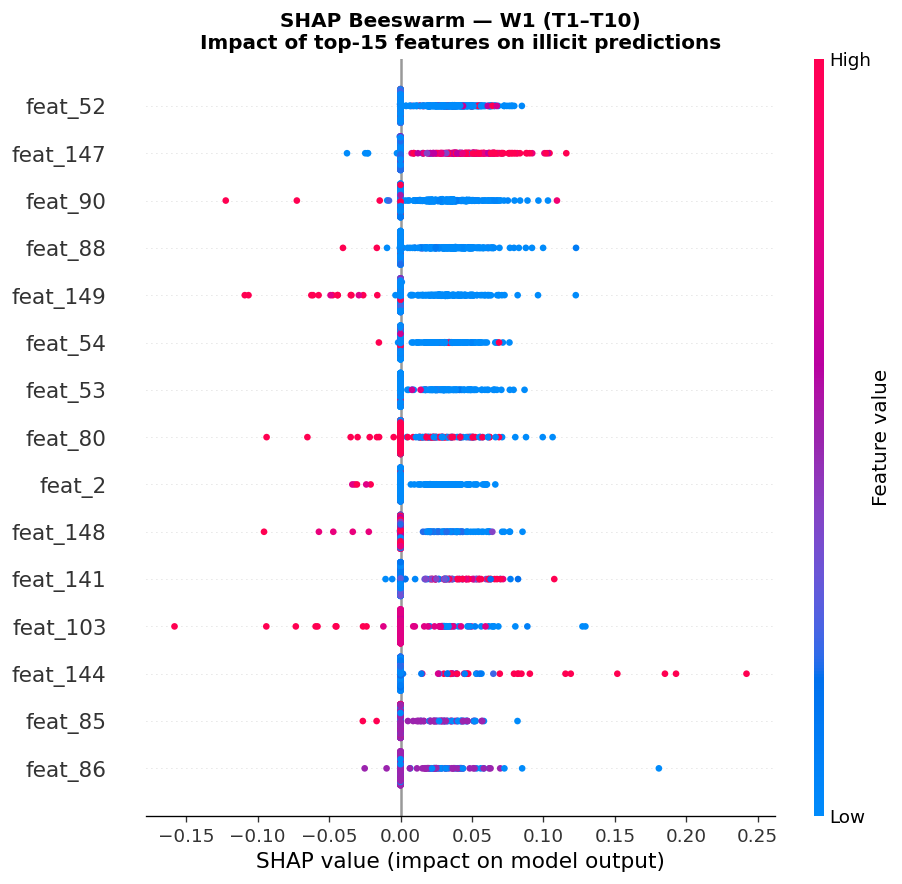

Saved → /content/drive/MyDrive/Capstone/Testing/figures/shap_beeswarm_W1.png


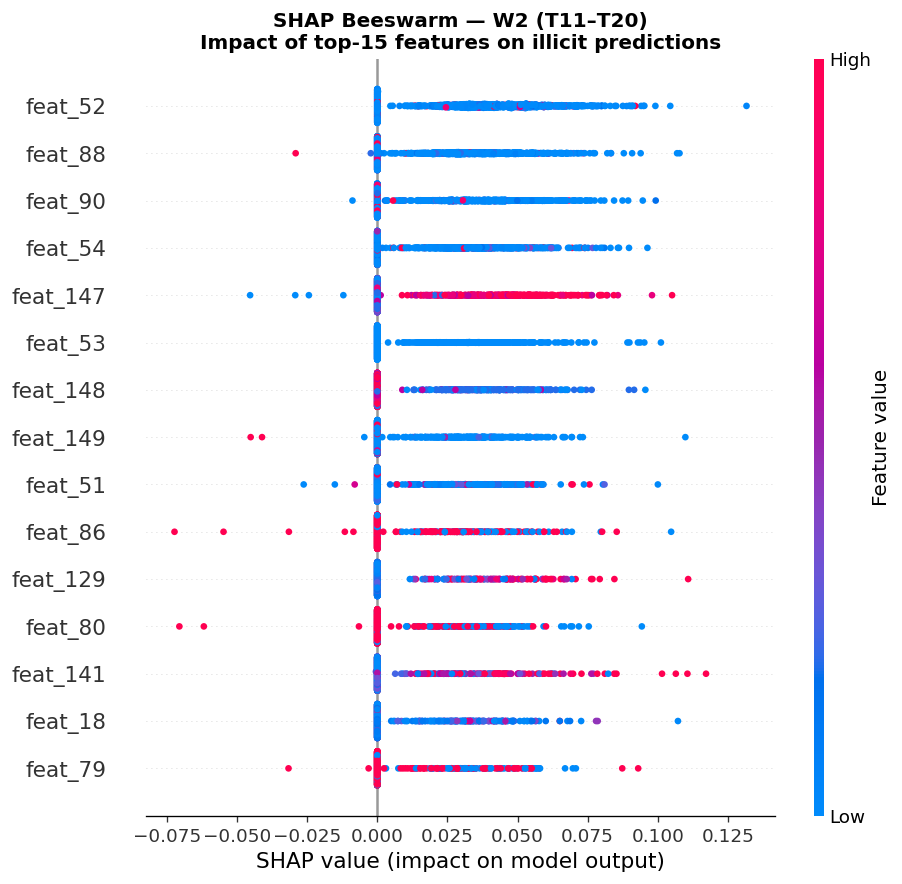

Saved → /content/drive/MyDrive/Capstone/Testing/figures/shap_beeswarm_W2.png


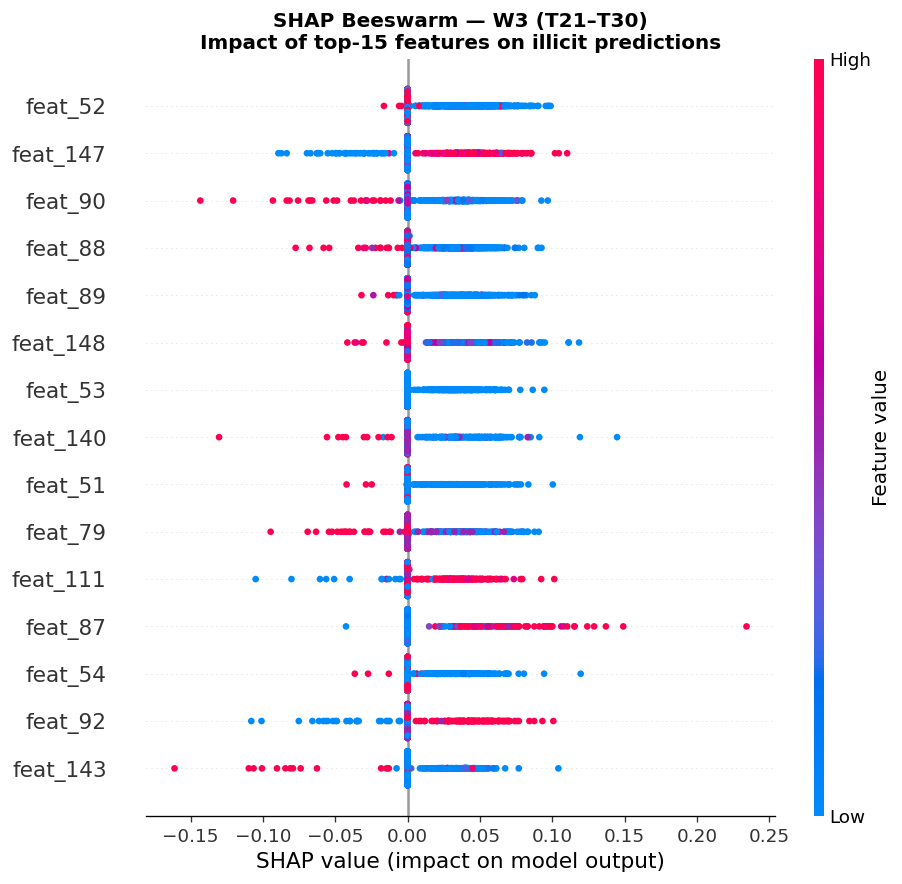

Saved → /content/drive/MyDrive/Capstone/Testing/figures/shap_beeswarm_W3.png


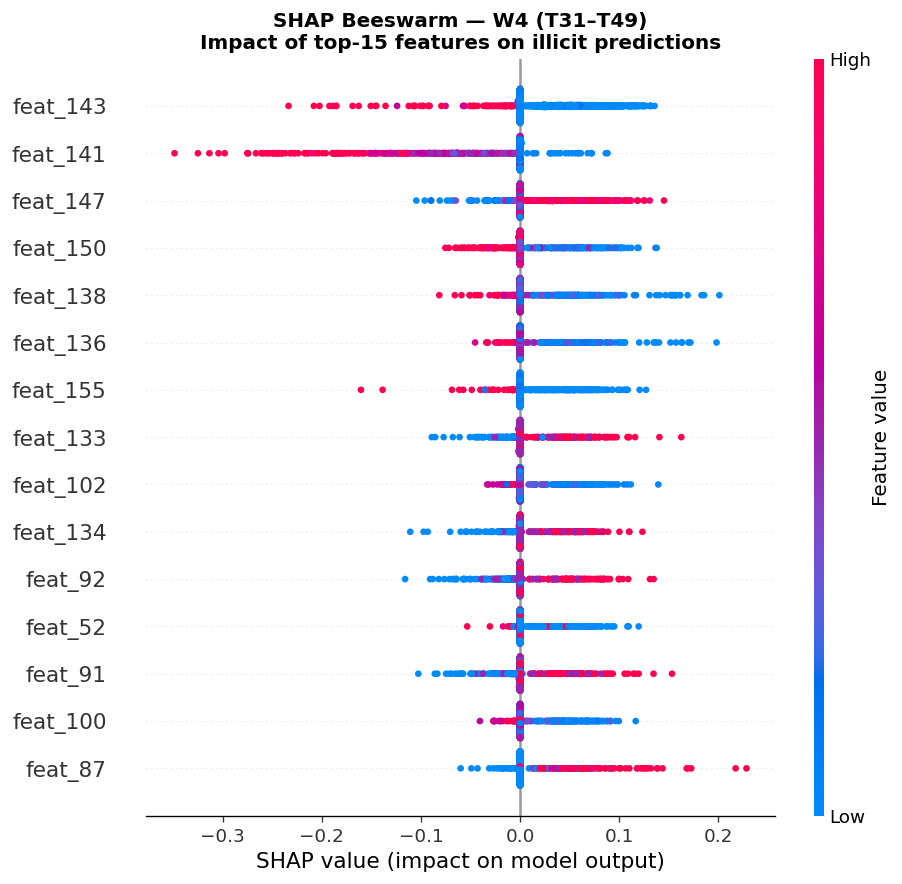

Saved → /content/drive/MyDrive/Capstone/Testing/figures/shap_beeswarm_W4.png


In [28]:
import shap
import matplotlib.pyplot as plt

# ── Beeswarm plots for each window ────────────────────────────────────────────
for window_name, res in shap_results.items():
    shap_vals  = res['shap_values']   # shape: (n_illicit_sampled, 165)
    X_illicit  = res['X_illicit']     # shape: (n_illicit_sampled, 165)
    time_range = res['time_range']

    # Only plot top 15 features for readability
    top15_idx   = res['ranked_idx'][:15]
    shap_top15  = shap_vals[:, top15_idx]
    X_top15     = X_illicit[:, top15_idx]
    feat_names  = [f'feat_{i}' for i in top15_idx]

    # Build SHAP Explanation object
    explanation = shap.Explanation(
        values          = shap_top15,
        data            = X_top15,
        feature_names   = feat_names,
    )

    fig, ax = plt.subplots(figsize=(10, 7))
    shap.plots.beeswarm(explanation, max_display=15, show=False)
    plt.title(f'SHAP Beeswarm — {window_name} ({time_range})\n'
              f'Impact of top-15 features on illicit predictions',
              fontsize=12, fontweight='bold')
    plt.tight_layout()
    out_path = os.path.join(FIGURES_DIR, f'shap_beeswarm_{window_name}.png')
    plt.savefig(out_path, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f'Saved → {out_path}')

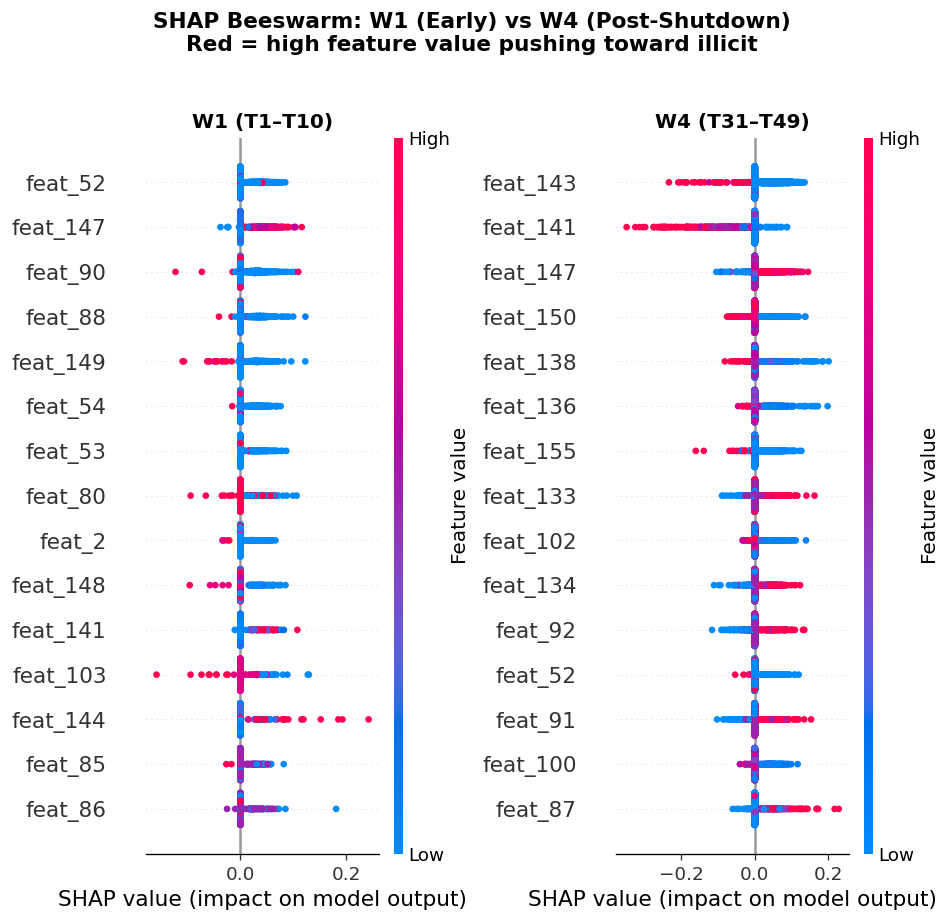

Saved → /content/drive/MyDrive/Capstone/Testing/figures/shap_beeswarm_w1_vs_w4.png


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, window_name, in zip(axes, ['W1', 'W4']):
    res        = shap_results[window_name]
    shap_vals  = res['shap_values']
    X_illicit  = res['X_illicit']
    top15_idx  = res['ranked_idx'][:15]
    feat_names = [f'feat_{i}' for i in top15_idx]

    explanation = shap.Explanation(
        values        = shap_vals[:, top15_idx],
        data          = X_illicit[:, top15_idx],
        feature_names = feat_names,
    )

    plt.sca(ax)
    shap.plots.beeswarm(explanation, max_display=15, show=False)
    ax.set_title(f'{window_name} ({res["time_range"]})',
                 fontsize=12, fontweight='bold')

plt.suptitle('SHAP Beeswarm: W1 (Early) vs W4 (Post-Shutdown)\n'
             'Red = high feature value pushing toward illicit',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
out_path = os.path.join(FIGURES_DIR, 'shap_beeswarm_w1_vs_w4.png')
plt.savefig(out_path, bbox_inches='tight')
plt.show()
print(f'Saved → {out_path}')

---
## Cell 9 — Compute Kendall τ Between Consecutive Windows

In [30]:
window_names = list(shap_results.keys())
tau_results  = []

def tau_on_union(imp_a, imp_b, ranked_a, ranked_b, k=TOP_K_TAU):
    union = sorted(set(ranked_a[:k]) | set(ranked_b[:k]))
    ra = np.argsort(np.argsort(-imp_a[union]))
    rb = np.argsort(np.argsort(-imp_b[union]))
    tau, pval = kendalltau(ra, rb)
    return tau, pval, union

print(f'KENDALL τ — CONSECUTIVE WINDOWS   (model = {MODEL_NAME})')
print('=' * 70)
print(f'  top-{TOP_K_TAU} union per pair  |  drift threshold τ < {TAU_THRESHOLD}')
print()
print(f'  {"Comparison":<12} {"τ":>8}  {"p":>8}  {"95% CI (bootstrap)":>22}  {"perm p":>8}  Status')
print(f'  {"-"*72}')

rng = np.random.default_rng(SEED)
for i in range(len(window_names) - 1):
    w_a, w_b = window_names[i], window_names[i + 1]
    ra, rb   = shap_results[w_a], shap_results[w_b]
    tau, pval, union = tau_on_union(ra['importance'], rb['importance'],
                                    ra['ranked_idx'], rb['ranked_idx'])

    # ── X4: bootstrap CI — resample illicit nodes, recompute importance & τ ──
    sv_a, sv_b = ra['shap_values'], rb['shap_values']
    boot = []
    for _ in range(N_BOOTSTRAP):
        ia = rng.integers(0, sv_a.shape[0], sv_a.shape[0])
        ib = rng.integers(0, sv_b.shape[0], sv_b.shape[0])
        imp_a = np.abs(sv_a[ia]).mean(0)
        imp_b = np.abs(sv_b[ib]).mean(0)
        rk_a  = np.argsort(imp_a)[::-1]
        rk_b  = np.argsort(imp_b)[::-1]
        t_b, _, _ = tau_on_union(imp_a, imp_b, rk_a, rk_b)
        if not np.isnan(t_b):
            boot.append(t_b)
    ci_lo, ci_hi = (np.percentile(boot, 2.5), np.percentile(boot, 97.5)) if boot else (np.nan, np.nan)

    # ── X4: permutation test — null = feature rankings unrelated ────────────
    imp_a_u = ra['importance'][union]
    imp_b_u = rb['importance'][union]
    base_rank_a = np.argsort(np.argsort(-imp_a_u))
    base_rank_b = np.argsort(np.argsort(-imp_b_u))
    obs_tau, _  = kendalltau(base_rank_a, base_rank_b)
    perm_ge = 0
    for _ in range(N_PERMUTATION):
        pt, _ = kendalltau(base_rank_a, rng.permutation(base_rank_b))
        if abs(pt) >= abs(obs_tau):
            perm_ge += 1
    perm_p = (perm_ge + 1) / (N_PERMUTATION + 1)

    drift = tau < TAU_THRESHOLD
    flag  = '🚨 DRIFT' if drift else '✓ stable'
    print(f'  {w_a}→{w_b:<8} {tau:>8.4f}  {pval:>8.4f}  '
          f'[{ci_lo:>6.3f}, {ci_hi:>6.3f}]   {perm_p:>8.4f}  {flag}')

    tau_results.append({
        'comparison'  : f'{w_a}→{w_b}',
        'tau'         : round(float(tau), 4),
        'pval'        : round(float(pval), 6),
        'ci_low'      : round(float(ci_lo), 4),
        'ci_high'     : round(float(ci_hi), 4),
        'perm_pvalue' : round(float(perm_p), 4),
        'n_union'     : len(union),
        'drift'       : bool(drift),
    })

payload = {'model': MODEL_NAME, 'top_k_tau': TOP_K_TAU, 'threshold': TAU_THRESHOLD,
           'n_bootstrap': N_BOOTSTRAP, 'n_permutation': N_PERMUTATION,
           'results': tau_results}
with open(TAU_JSON, 'w') as f:
    json.dump(payload, f, indent=2)
print(f'\nSaved → {TAU_JSON}')

KENDALL τ — CONSECUTIVE WINDOWS   (model = evolvegcn)
  top-15 union per pair  |  drift threshold τ < 0.7

  Comparison          τ         p      95% CI (bootstrap)    perm p  Status
  ------------------------------------------------------------------------
  W1→W2         0.4971    0.0024  [ 0.389,  0.569]     0.0030  🚨 DRIFT
  W2→W3         0.2762    0.0852  [ 0.169,  0.358]     0.0849  🚨 DRIFT
  W3→W4        -0.3867    0.0063  [-0.422, -0.280]     0.0090  🚨 DRIFT

Saved → /content/drive/MyDrive/Capstone/Testing/data/shap/kendall_tau_evolvegcn.json


---
## Cell 10 — Kendall τ Plot

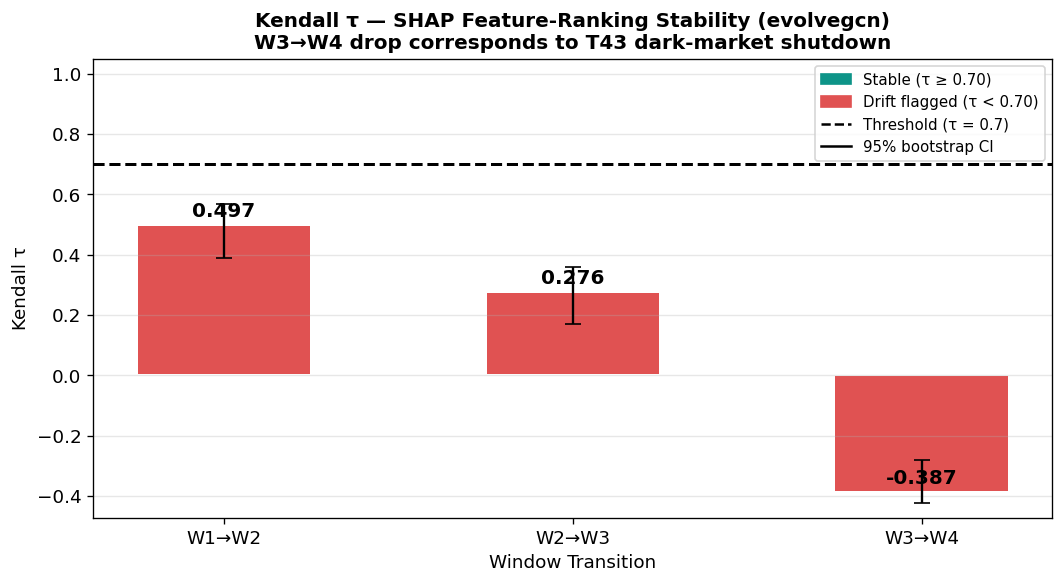

Saved → /content/drive/MyDrive/Capstone/Testing/figures/kendall_tau_evolvegcn.png


In [31]:
comparisons = [r['comparison'] for r in tau_results]
taus        = [r['tau']        for r in tau_results]
ci_lo       = [r['tau'] - r['ci_low']  for r in tau_results]
ci_hi       = [r['ci_high'] - r['tau'] for r in tau_results]
colors      = ['#E05252' if r['drift'] else '#0D9488' for r in tau_results]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(comparisons, taus, color=colors, width=0.5, edgecolor='white', linewidth=1.2)
ax.errorbar(range(len(taus)), taus, yerr=[ci_lo, ci_hi], fmt='none',
            ecolor='black', capsize=5, linewidth=1.4, label='95% bootstrap CI')
ax.axhline(y=TAU_THRESHOLD, color='black', linestyle='--', linewidth=1.8,
           label=f'Drift threshold (τ = {TAU_THRESHOLD})')
for bar, t in zip(bars, taus):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
            f'{t:.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#0D9488', label='Stable (τ ≥ 0.70)'),
    Patch(color='#E05252', label='Drift flagged (τ < 0.70)'),
    plt.Line2D([0], [0], color='black', linestyle='--', label=f'Threshold (τ = {TAU_THRESHOLD})'),
    plt.Line2D([0], [0], color='black', label='95% bootstrap CI'),
], fontsize=9)
ax.set_ylim(min(0, min(t - l for t, l in zip(taus, ci_lo)) - 0.05), 1.05)
ax.set_title(f'Kendall τ — SHAP Feature-Ranking Stability ({MODEL_NAME})\n'
             'W3→W4 drop corresponds to T43 dark-market shutdown',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Window Transition'); ax.set_ylabel('Kendall τ')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
out_path = os.path.join(FIGURES_DIR, f'kendall_tau_{MODEL_NAME}.png')
plt.savefig(out_path, bbox_inches='tight'); plt.show()
print(f'Saved → {out_path}')

---
### X5 — Local vs aggregated feature shift

Elliptic features split into **local** (`feat_0`–`feat_93`, transaction-level) and
**aggregated** (`feat_94`–`feat_164`, one-hop neighbourhood). We quantify the fraction of
each window's top-K that is local vs aggregated. Expected, model-independent finding:
post-shutdown the model leans more on aggregated / neighbourhood features. This is
publishable regardless of which model wins the F1 race.

LOCAL vs AGGREGATED — fraction of top-10 features   (model = evolvegcn)
  local = feat_0..feat_93   aggregated = feat_94..feat_164

  Window     Local  Aggregated   Top features
  --------------------------------------------------------
  W1          0.70        0.30   ['feat_52', 'feat_147', 'feat_90', 'feat_88', 'feat_149']
  W2          0.70        0.30   ['feat_52', 'feat_88', 'feat_90', 'feat_54', 'feat_147']
  W3          0.70        0.30   ['feat_52', 'feat_147', 'feat_90', 'feat_88', 'feat_89']
  W4          0.00        1.00   ['feat_143', 'feat_141', 'feat_147', 'feat_150', 'feat_138']


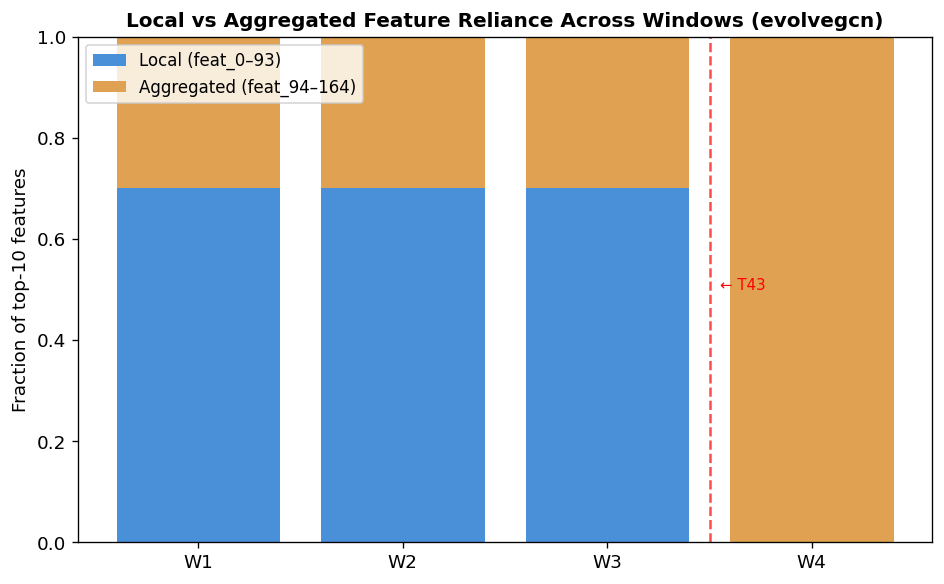


Saved → /content/drive/MyDrive/Capstone/Testing/figures/local_vs_aggregated_evolvegcn.png


In [32]:
K_SHIFT = 10
print(f'LOCAL vs AGGREGATED — fraction of top-{K_SHIFT} features   (model = {MODEL_NAME})')
print('=' * 60)
print(f'  local = feat_0..feat_{LOCAL_MAX}   aggregated = feat_{LOCAL_MAX+1}..feat_{NUM_FEATURES-1}')
print()
print(f'  {"Window":<8}{"Local":>8}{"Aggregated":>12}   Top features')
print('  ' + '-'*56)

x5 = []
for w_name, res in shap_results.items():
    topk = res['ranked_idx'][:K_SHIFT]
    n_local = int(sum(1 for f in topk if f <= LOCAL_MAX))
    n_agg   = K_SHIFT - n_local
    x5.append({'window': w_name, 'time_range': res['time_range'],
               'local_frac': round(n_local / K_SHIFT, 3),
               'agg_frac':   round(n_agg / K_SHIFT, 3),
               'top_features': [f'feat_{i}' for i in topk]})
    print(f'  {w_name:<8}{n_local/K_SHIFT:>8.2f}{n_agg/K_SHIFT:>12.2f}   '
          f'{[f"feat_{i}" for i in topk[:5]]}')

# Stacked bar
fig, ax = plt.subplots(figsize=(8, 5))
wn      = [r['window'] for r in x5]
locals_ = [r['local_frac'] for r in x5]
aggs    = [r['agg_frac']   for r in x5]
ax.bar(wn, locals_, color='#4A90D9', label='Local (feat_0–93)')
ax.bar(wn, aggs, bottom=locals_, color='#E0A252', label='Aggregated (feat_94–164)')
ax.axvline(2.5, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
ax.text(2.55, 0.5, '← T43', color='red', fontsize=9)
ax.set_ylabel(f'Fraction of top-{K_SHIFT} features'); ax.set_ylim(0, 1)
ax.set_title(f'Local vs Aggregated Feature Reliance Across Windows ({MODEL_NAME})',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
out_path = os.path.join(FIGURES_DIR, f'local_vs_aggregated_{MODEL_NAME}.png')
plt.savefig(out_path, bbox_inches='tight'); plt.show()

with open(os.path.join(SHAP_DIR, f'local_vs_aggregated_{MODEL_NAME}.json'), 'w') as f:
    json.dump({'model': MODEL_NAME, 'top_k': K_SHIFT, 'windows': x5}, f, indent=2)
print(f'\nSaved → {out_path}')

---
## Cell 11 — SHAP Bar Charts: W1 vs W4 Side by Side

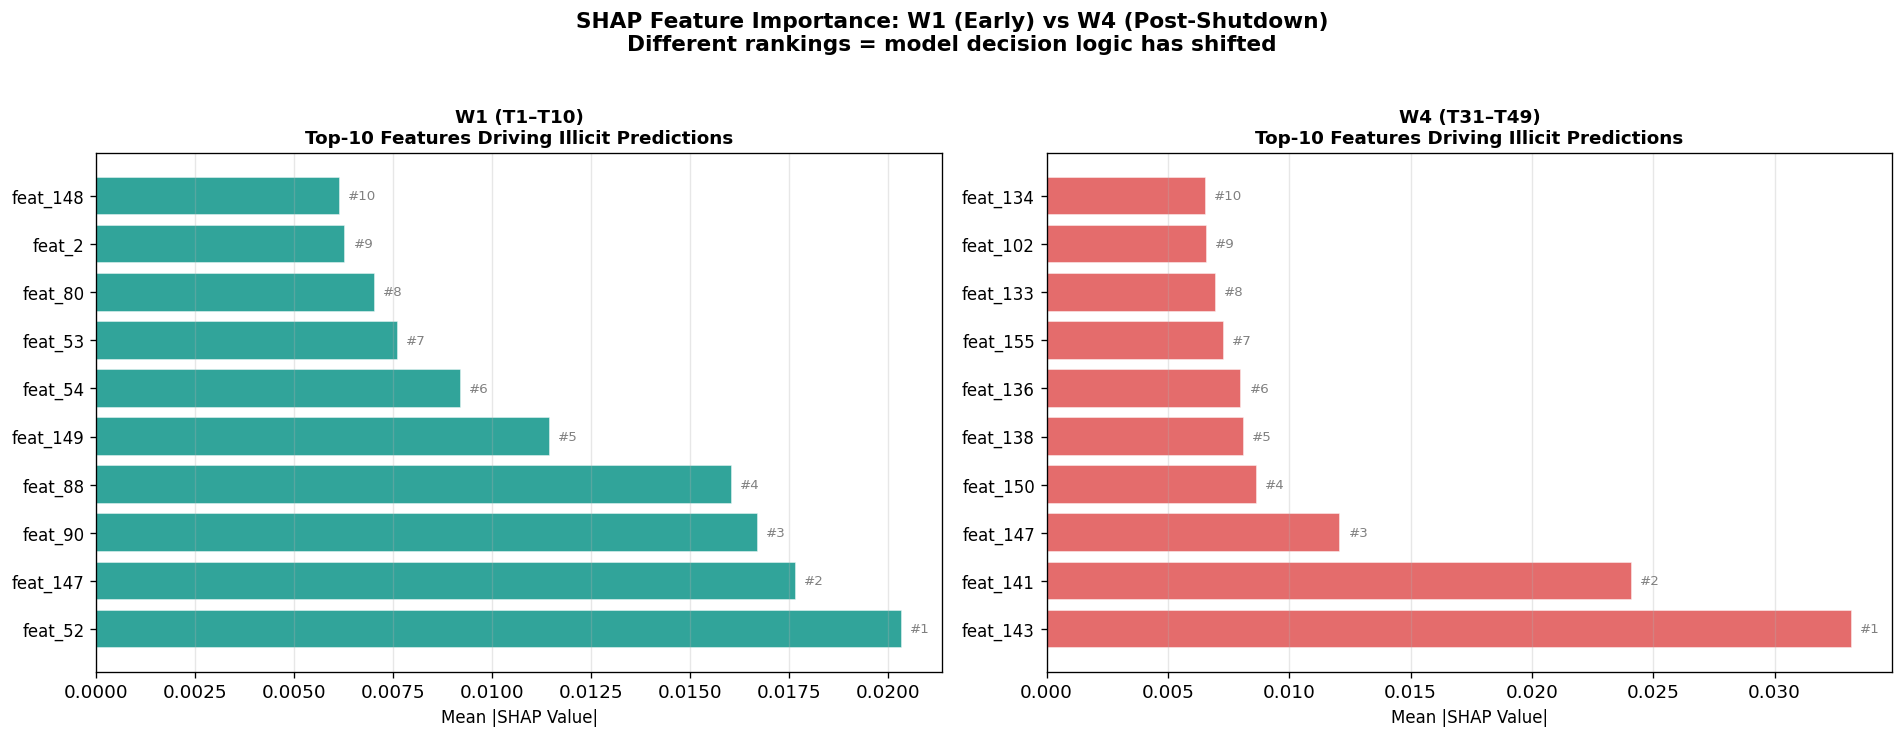

Saved → /content/drive/MyDrive/Capstone/Testing/figures/shap_w1_vs_w4.png


In [33]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, window_name, color in [
    (axes[0], 'W1', '#0D9488'),
    (axes[1], 'W4', '#E05252'),
]:
    res      = shap_results[window_name]
    top_feat = res['top10_names']
    top_vals = res['top10_vals']

    # Plot horizontal bars (most important at top)
    y_pos = range(TOP_K - 1, -1, -1)
    ax.barh(list(y_pos), top_vals[::-1], color=color, alpha=0.85, edgecolor='white')
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(top_feat[::-1], fontsize=10)
    ax.set_xlabel('Mean |SHAP Value|', fontsize=10)
    ax.set_title(f'{window_name} ({res["time_range"]})\nTop-10 Features Driving Illicit Predictions',
                 fontsize=11, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)

    # Rank labels
    for rank, (y, val) in enumerate(zip(y_pos, top_vals[::-1]), start=1):
        ax.text(val + max(top_vals)*0.01, y, f'#{TOP_K - rank + 1}',
                va='center', fontsize=8, color='gray')

plt.suptitle('SHAP Feature Importance: W1 (Early) vs W4 (Post-Shutdown)\n'
             'Different rankings = model decision logic has shifted',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
out_path = os.path.join(FIGURES_DIR, 'shap_w1_vs_w4.png')
plt.savefig(out_path, bbox_inches='tight')
plt.show()
print(f'Saved → {out_path}')

---
## Cell 12 — SHAP Heatmap Across All 4 Windows

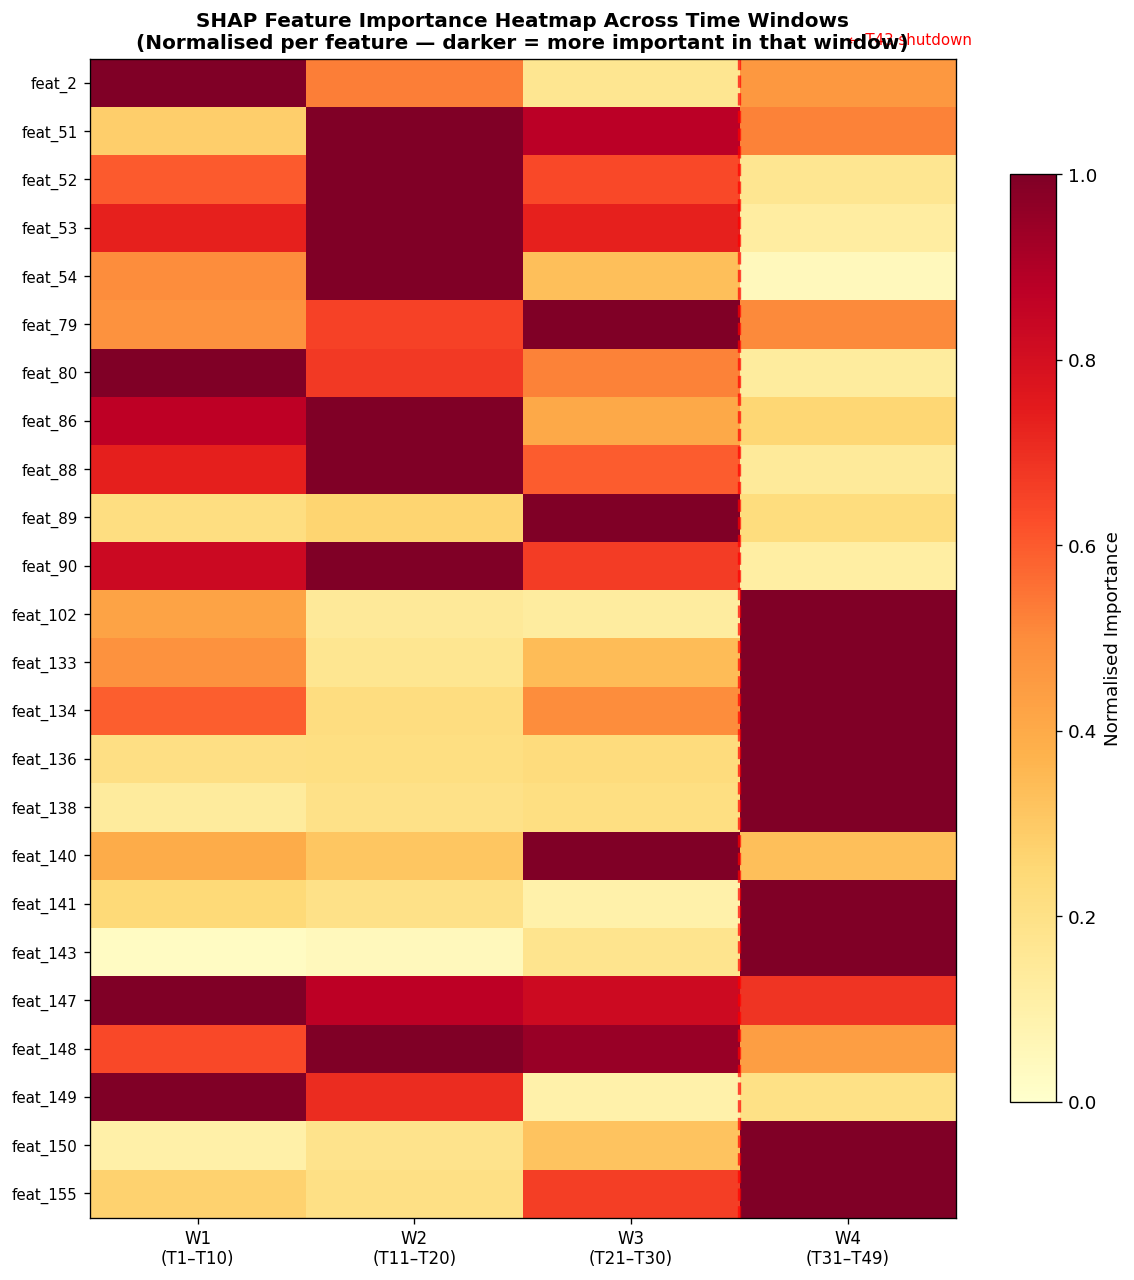

Saved → /content/drive/MyDrive/Capstone/Testing/figures/shap_heatmap_all_windows.png


In [34]:
# Find the union of top-10 features across all windows
all_top_features = set()
for res in shap_results.values():
    all_top_features.update(res['top10_names'])
all_top_features = sorted(all_top_features,
    key=lambda f: int(f.split('_')[1]))  # sort by feature index

# Build heatmap matrix: rows = features, cols = windows
heatmap_data = np.zeros((len(all_top_features), len(WINDOWS)))
for col, (w_name, res) in enumerate(shap_results.items()):
    for row, feat in enumerate(all_top_features):
        feat_idx = int(feat.split('_')[1])
        heatmap_data[row, col] = res['importance'][feat_idx]

# Normalise each row to 0–1 for visual clarity
row_max = heatmap_data.max(axis=1, keepdims=True)
row_max[row_max == 0] = 1
heatmap_norm = heatmap_data / row_max

fig, ax = plt.subplots(figsize=(10, max(6, len(all_top_features) * 0.45)))
im = ax.imshow(heatmap_norm, aspect='auto', cmap='YlOrRd', vmin=0, vmax=1)

ax.set_xticks(range(len(WINDOWS)))
ax.set_xticklabels(
    [f'{w}\n({res["time_range"]})' for w, res in shap_results.items()],
    fontsize=10
)
ax.set_yticks(range(len(all_top_features)))
ax.set_yticklabels(all_top_features, fontsize=9)
ax.set_title('SHAP Feature Importance Heatmap Across Time Windows\n'
             '(Normalised per feature — darker = more important in that window)',
             fontsize=12, fontweight='bold')

plt.colorbar(im, ax=ax, label='Normalised Importance', shrink=0.8)

# Mark W4 column (contains T43)
ax.axvline(x=2.5, color='red', linewidth=2, linestyle='--', alpha=0.7)
ax.text(3.0, -0.8, '← T43 shutdown', color='red', fontsize=9, ha='left')

plt.tight_layout()
out_path = os.path.join(FIGURES_DIR, 'shap_heatmap_all_windows.png')
plt.savefig(out_path, bbox_inches='tight')
plt.show()
print(f'Saved → {out_path}')

---
## Cell 13 — T43 Prediction Table
Shows false negatives at the shutdown snapshot.  
Used in the demo to illustrate concept drift in action.

In [35]:
# T43 prediction table (index 42). For EvolveGCN we warm up T1→T43 first.
T43_IDX  = 42
snap_t43 = snapshots[T43_IDX]

model.eval()
with torch.no_grad():
    if MODEL_NAME == 'evolvegcn':
        model.reset_state('cpu')
        for i in range(0, T43_IDX + 1):          # evolve up to and including T43
            logits, _ = model(snapshots[i].x, snapshots[i].edge_index)
    else:
        logits, _ = model(snap_t43.x, snap_t43.edge_index)
    probs = torch.softmax(logits, dim=1)
    preds = logits.argmax(dim=1)

y_true, y_pred = snap_t43.y.numpy(), preds.numpy()
confidence, tx_ids = probs.numpy(), snap_t43.tx_ids.numpy()
label_map = {-1: 'Unknown', 0: 'Licit', 1: 'Illicit'}

illicit_mask = (y_true == 1)
n_illicit = int(illicit_mask.sum())
n_correct = int(((y_pred == 1) & illicit_mask).sum())
n_missed  = int(((y_pred == 0) & illicit_mask).sum())

print(f'SNAPSHOT T43 — PREDICTION SUMMARY  ({MODEL_NAME})')
print('=' * 50)
print(f'  Illicit nodes            : {n_illicit}')
print(f'  Correctly flagged (TP)   : {n_correct}')
print(f'  Missed (FN)              : {n_missed}   ← concept-drift evidence')
print()
print('ILLICIT NODES AT T43 — WERE THEY CAUGHT?')
print(f'{"Tx ID":>12}  {"True":>8}  {"Pred":>8}  {"Conf":>8}  Result')
print('-' * 55)
for idx in np.where(illicit_mask)[0][:20]:
    conf   = confidence[idx][y_pred[idx]]
    result = '✓ Caught' if y_pred[idx] == 1 else '✗ MISSED'
    print(f'{tx_ids[idx]:>12}  {label_map[y_true[idx]]:>8}  '
          f'{label_map[y_pred[idx]]:>8}  {conf:>8.4f}  {result}')
if n_illicit > 20:
    print(f'  ... and {n_illicit - 20} more illicit nodes')

import csv
table_path = os.path.join(SHAP_DIR, f't43_predictions_{MODEL_NAME}.csv')
with open(table_path, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['tx_id', 'true_label', 'predicted', 'conf_licit', 'conf_illicit', 'result'])
    for idx in np.where(illicit_mask)[0]:
        writer.writerow([tx_ids[idx], label_map[y_true[idx]], label_map[y_pred[idx]],
                         round(float(confidence[idx][0]), 4),
                         round(float(confidence[idx][1]), 4),
                         'Caught' if y_pred[idx] == 1 else 'Missed'])
print(f'\nSaved → {table_path}')

SNAPSHOT T43 — PREDICTION SUMMARY  (evolvegcn)
  Illicit nodes            : 24
  Correctly flagged (TP)   : 1
  Missed (FN)              : 23   ← concept-drift evidence

ILLICIT NODES AT T43 — WERE THEY CAUGHT?
       Tx ID      True      Pred      Conf  Result
-------------------------------------------------------
    94340906   Illicit     Licit    0.9617  ✗ MISSED
    94940927   Illicit     Licit    1.0000  ✗ MISSED
    94626460   Illicit     Licit    0.9488  ✗ MISSED
    94153016   Illicit     Licit    1.0000  ✗ MISSED
    92735262   Illicit     Licit    1.0000  ✗ MISSED
    94153268   Illicit     Licit    1.0000  ✗ MISSED
    94336035   Illicit     Licit    1.0000  ✗ MISSED
    92021053   Illicit     Licit    0.9902  ✗ MISSED
    94153275   Illicit     Licit    0.9950  ✗ MISSED
    94341464   Illicit     Licit    1.0000  ✗ MISSED
    94150348   Illicit     Licit    0.9999  ✗ MISSED
    94255570   Illicit     Licit    0.9996  ✗ MISSED
    94341503   Illicit     Licit    1.0000  ✗ 

---
## Cell 14 — Summary of All Saved Files

In [36]:
print(f'ALL OUTPUTS SAVED — model = {MODEL_NAME}')
print('=' * 60)
print('\nSHAP data (data/shap/):')
for w in WINDOWS:
    p = shap_path(w)
    size = os.path.getsize(p) / 1024 if os.path.exists(p) else 0
    print(f'  {os.path.basename(p):<28} {size:.0f} KB')
print(f'  {os.path.basename(TAU_JSON)}')
print(f'  local_vs_aggregated_{MODEL_NAME}.json')
print(f'  t43_predictions_{MODEL_NAME}.csv')

print('\nFigures (figures/):')
for fig_file in [f'kendall_tau_{MODEL_NAME}.png',
                 f'local_vs_aggregated_{MODEL_NAME}.png']:
    p = os.path.join(FIGURES_DIR, fig_file)
    print(f'  {fig_file:<40} {"✓" if os.path.exists(p) else "✗ missing"}')

print('\nMAKE-OR-BREAK CHECK:')
print('  Compare kendall_tau_static.json vs kendall_tau_evolvegcn.json (W3→W4 τ).')
print('  Static W3→W4 τ ≈ 0.147.  EvolveGCN should be HIGHER for the "more stable')
print('  decision logic" claim. If marginal → use the fallback framings (CHANGE_LIST.md).')
print('\nRun again with the OTHER MODEL_NAME to produce the paired result.')

ALL OUTPUTS SAVED — model = evolvegcn

SHAP data (data/shap/):
  shap_evolvegcn_W1.pkl        1016 KB
  shap_evolvegcn_W2.pkl        2414 KB
  shap_evolvegcn_W3.pkl        2291 KB
  shap_evolvegcn_W4.pkl        3080 KB
  kendall_tau_evolvegcn.json
  local_vs_aggregated_evolvegcn.json
  t43_predictions_evolvegcn.csv

Figures (figures/):
  kendall_tau_evolvegcn.png                ✓
  local_vs_aggregated_evolvegcn.png        ✓

MAKE-OR-BREAK CHECK:
  Compare kendall_tau_static.json vs kendall_tau_evolvegcn.json (W3→W4 τ).
  Static W3→W4 τ ≈ 0.147.  EvolveGCN should be HIGHER for the "more stable
  decision logic" claim. If marginal → use the fallback framings (CHANGE_LIST.md).

Run again with the OTHER MODEL_NAME to produce the paired result.
